# Reward-net input patterns → predicted reward

Loads the weights and evaluation trajectories from a trained model, reconstructs **every input pattern** that
gets fed to the reward-predictor net (`reward_net.apply(params, rp_in, method=A2CRNNFlax.predict_reward)`),
finds the **unique** ones, and shows a heatmap of each unique input pattern next to the reward the net predicts for it.

Each reward-net input `rp_in` is a length-`K*obs + action + 1` vector:
`[ flattened K-step obs window ending at s , anchor-action one-hot , normalized lag j = (s-t)/RPE_H ]`.

In [11]:
import os, sys
os.environ.setdefault('JAX_PLATFORM_NAME', 'cpu')
sys.path.insert(0, os.path.abspath('..'))          # code/  (agents, environments, ...)
sys.path.insert(0, os.path.abspath('../scripts'))  # training script module (optional)

import pickle
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import TwoSlopeNorm
from flax.training import checkpoints

from agents.a2c_rnn_reward_pred_flax import A2CRNNFlax, init_network_and_params
from aux_funcs import format_plot

## Model / run configuration

Point `CKPT_DIR` and `TRAJ_PATH` at the model you want. The dims below match the run's saved `TrainingConfig`
(`obs_size=4, hidden_size=64, GRU, action_size=2`) and the reward-net hyperparameters from the training script
(`RPE_K=4, RPE_H=20, REWARD_PRED_HIDDEN=64`). The assert on the restored kernel shape guards against a mismatch.

In [43]:
REPO = os.path.abspath('../..')

# results/persistence_gated_exp_gru_initial_prob_offset_long_v7/trajectories_20260804_135221.pkl',

EXP      = 'persistence_gated_exp_gru_initial_prob_offset_long_v7'
CKPT_DIR = f'{REPO}/checkpoints/{EXP}'                                      # restores checkpoint_0 (best)
TRAJ_PATH = f'{REPO}/results/{EXP}/trajectories_20260804_135221.pkl'
CKPT_STEP = 0   # which checkpoint in CKPT_DIR (0 = the main saved model); e.g. use a snapshots/ dir + step for others

# --- dims from the run's TrainingConfig ---
OBS, ACT, HID, RNN = 4, 2, 64, 'GRU'
# --- reward-net hyperparameters (must match training: train_treadmill_agent_jax_reward_gated_logits.py) ---
RPE_K, RPE_H, REWARD_PRED_HIDDEN = 4, 20, 64
WINDOW_DIM = RPE_K * OBS + ACT + 1
print('reward-net input dim (window_dim) =', WINDOW_DIM)

reward-net input dim (window_dim) = 19


In [38]:
REPO = os.path.abspath('../..')

EXP      = 'persistence_gated_exp_gru_initial_prob_offset_long_v3'
CKPT_DIR = f'{REPO}/checkpoints/{EXP}'                                      # restores checkpoint_0 (best)
TRAJ_PATH = f'{REPO}/results/{EXP}/trajectories/traj_000100.pkl'
CKPT_STEP = 0   # which checkpoint in CKPT_DIR (0 = the main saved model); e.g. use a snapshots/ dir + step for others

# --- dims from the run's TrainingConfig ---
OBS, ACT, HID, RNN = 4, 2, 64, 'GRU'
# --- reward-net hyperparameters (must match training: train_treadmill_agent_jax_reward_gated_logits.py) ---
RPE_K, RPE_H, REWARD_PRED_HIDDEN = 4, 20, 64
WINDOW_DIM = RPE_K * OBS + ACT + 1
print('reward-net input dim (window_dim) =', WINDOW_DIM)

reward-net input dim (window_dim) = 19


In [45]:
# Build a param-tree target (needed to restore on CPU: the checkpoint carries device/sharding metadata),
# then restore the trained weights into it.
_, params0 = init_network_and_params(
    HID, ACT, OBS, RNN, 0.0, jax.random.key(0),
    reward_pred_hidden_size=REWARD_PRED_HIDDEN, window_dim=WINDOW_DIM,
)
restored = checkpoints.restore_checkpoint(ckpt_dir=CKPT_DIR, target={'params': params0}, step=CKPT_STEP)
params = restored['params']

k_shape = np.asarray(params['params']['reward_pred_l1']['kernel']).shape
assert k_shape == (WINDOW_DIM, REWARD_PRED_HIDDEN), (k_shape, (WINDOW_DIM, REWARD_PRED_HIDDEN))
print('restored weights; reward_pred_l1 kernel:', k_shape)

# reward-net apply (predict_reward path only)
reward_net = A2CRNNFlax(action_size=ACT, hidden_size=HID, unit_noise_std=0.0,
                        rnn_type=RNN, obs_size=OBS, reward_pred_hidden_size=REWARD_PRED_HIDDEN)
predict_reward = jax.jit(lambda inp: reward_net.apply(params, inp, method=A2CRNNFlax.predict_reward))

restored weights; reward_pred_l1 kernel: (19, 64)


In [46]:
with open(TRAJ_PATH, 'rb') as f:
    trajs = pickle.load(f)
print(f'loaded {len(trajs)} trajectories')
obs0 = np.asarray(trajs[0]['observations'])
print('observations shape (per traj):', obs0.shape, '  [obs_size | prev-action one-hot | prev-reward]')
# The distinct sensory observation vectors seen (the first obs_size columns):
distinct_obs = np.unique(obs0[:, :OBS], axis=0)
print('distinct sensory obs vectors:')
print(distinct_obs)

loaded 30 trajectories
observations shape (per traj): (20000, 7)   [obs_size | prev-action one-hot | prev-reward]
distinct sensory obs vectors:
[[ 0. -0.  0. -0.]
 [ 1. -0.  0.  0.]
 [ 1.  0.  0.  1.]
 [ 1.  0.  1.  0.]
 [ 1.  1. -0.  0.]]


## Reconstruct every reward-net input, then keep the unique ones

This mirrors how `rp_in` is built inside `compute_a2c_loss`: for each anchor time `t` (with its action `a_t`) and
each lag `j = 0..RPE_H`, the input is the `K`-step obs window ending at `s = t + j`, the one-hot of `a_t`, and the
normalized lag `j / RPE_H`. We take the union of unique input rows across all trajectories.

In [47]:
def trajectory_inputs(traj):
    """All reward-net input rows (T*(H+1) minus right-boundary, WINDOW_DIM) for one trajectory."""
    feat = np.asarray(traj['observations'])[:, :OBS]          # (T, obs)  decision stimulus at each step
    # round feat to nearest integer
    feat = np.round(feat).astype(np.int32)
    acts = np.asarray(traj['actions'])                        # (T,)
    # round acts to nearest integer
    acts = np.round(acts).astype(np.int32)
    T = feat.shape[0]
    win_idx = np.clip(np.arange(T)[:, None] + np.arange(RPE_K)[None, :] - (RPE_K - 1), 0, T - 1)
    windows = feat[win_idx].reshape(T, RPE_K * OBS)           # (T, K*obs) window ending at each s
    act_oh = np.eye(ACT, dtype=np.float32)[acts]              # (T, A)
    out = []
    for j in range(RPE_H + 1):
        s = np.arange(T) + j
        keep = s < T                                          # drop targets past the chunk end
        s = np.clip(s, 0, T - 1)
        lag = np.full((T, 1), j / max(RPE_H, 1), np.float32)
        out.append(np.concatenate([windows[s], act_oh, lag], axis=1)[keep])
    return np.concatenate(out, axis=0)

# union of unique input rows across trajectories (unique per-traj first to keep it light)
seen, rows = set(), []
for traj in trajs:
    for r in np.unique(trajectory_inputs(traj), axis=0):
        key = r.tobytes()
        if key not in seen:
            seen.add(key); rows.append(r)
U = np.unique(np.asarray(rows, dtype=np.float32), axis=0)     # (M, WINDOW_DIM)
pred = np.asarray(predict_reward(jnp.asarray(U)))             # (M,)
print('unique reward-net input patterns:', U.shape[0])
print('predicted reward range: [%.4f, %.4f]  mean %.4f' % (pred.min(), pred.max(), pred.mean()))

unique reward-net input patterns: 2348
predicted reward range: [-0.0070, 0.3294]  mean 0.0027


## Each unique input pattern as a time × stimulus matrix

Each reward-net input's obs window is naturally a **`time × stimulus`** matrix (`K` window steps × `obs_size`
stimuli). Below, every unique `(obs-window, action)` input pattern is drawn as one little tile: **x = time**
(`t-3 … t`), **y = stimulus** (`obs` dims). The normalized lag scalar can't live in a time×stimulus matrix, so
it is collapsed here (see the next figure for the lag dependence) and the predicted reward shown is at
**lag 0** (= `p(r_t | a_t, history)`), encoded as each tile's **frame color**. `aN` = the anchor action.
Tiles are **ordered by similarity** (hierarchical-clustering leaf order), so nearby tiles are similar patterns.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


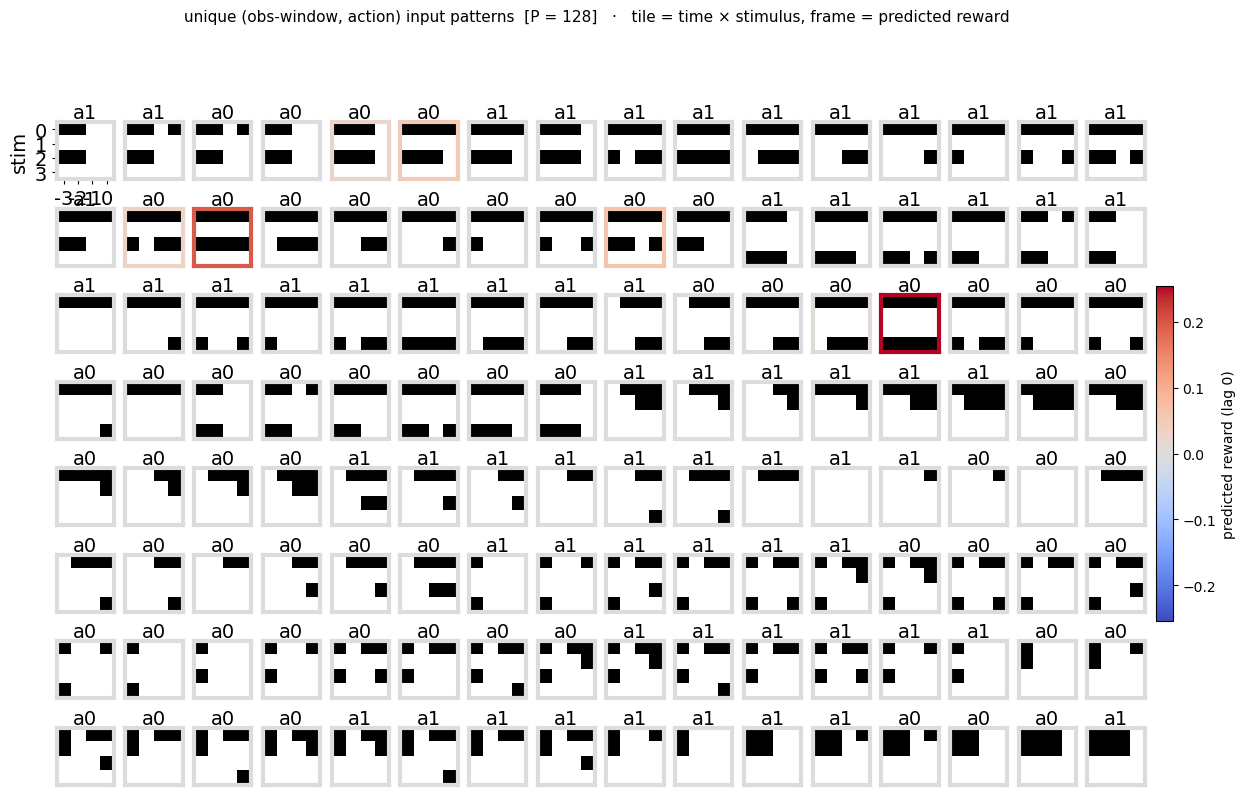

In [48]:
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib import cm

# one tile per unique (obs-window, action); predicted reward evaluated at lag 0
win_end, act_end = RPE_K * OBS, RPE_K * OBS + ACT
WA = np.unique(U[:, :act_end], axis=0)                                  # (P, K*obs + A)
P = WA.shape[0]
print(WA[0, :])
wa_in0 = np.concatenate([WA, np.zeros((P, 1), np.float32)], axis=1)     # append lag = 0
r0 = np.asarray(predict_reward(jnp.asarray(wa_in0)))                    # (P,)

wa_order = leaves_list(linkage(WA, method='ward', optimal_ordering=True))  # similar patterns adjacent
wins = WA[wa_order, :win_end].reshape(P, RPE_K, OBS)                    # (P, time, stimulus)
acts = WA[wa_order, win_end:act_end].argmax(1)
rr = r0[wa_order]

ncols = 16
nrows = int(np.ceil(P / ncols))
abs_max = np.max(np.abs(rr))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)
rmap = plt.get_cmap('coolwarm')

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 0.9, nrows * 1.1))
axes = np.atleast_2d(axes)
for i in range(nrows * ncols):
    ax = axes.flat[i]
    if i < P:
        ax.imshow(wins[i].T, cmap='Greys', vmin=0, vmax=1, aspect='equal')  # y=stimulus, x=time
        for sp in ax.spines.values():
            sp.set_color(rmap(norm(rr[i]))); sp.set_linewidth(3)
        ax.set_title(f'a{acts[i]}', fontsize=14, pad=1)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.axis('off')
# label the axis meaning on the first tile
a0 = axes.flat[0]
a0.set_xticks(range(RPE_K)); a0.set_xticklabels(range(-(RPE_K - 1), 1), fontsize=14)
a0.set_yticks(range(OBS)); a0.set_yticklabels(range(OBS), fontsize=14)
a0.set_xlabel('time', fontsize=6); a0.set_ylabel('stim', fontsize=14)

sm = cm.ScalarMappable(norm=norm, cmap=rmap); sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.01, label='predicted reward (lag 0)')
fig.suptitle(f'unique (obs-window, action) input patterns  [P = {P}]   ·   '
             f'tile = time × stimulus, frame = predicted reward', fontsize=11, y=1.0)
plt.show()

## Interpretable view: predicted reward vs. lag, per unique (obs-window, action)

The lag input mostly just rescales the same sensory/action pattern, so here we collapse it out: rows are the
unique `(obs-window, action)` patterns and columns are the lag `j`, colored by the net's predicted reward.
(`lag = 0` is exactly the `p(r_t | a_t, history)` prediction used as the reward baseline in the loss.)

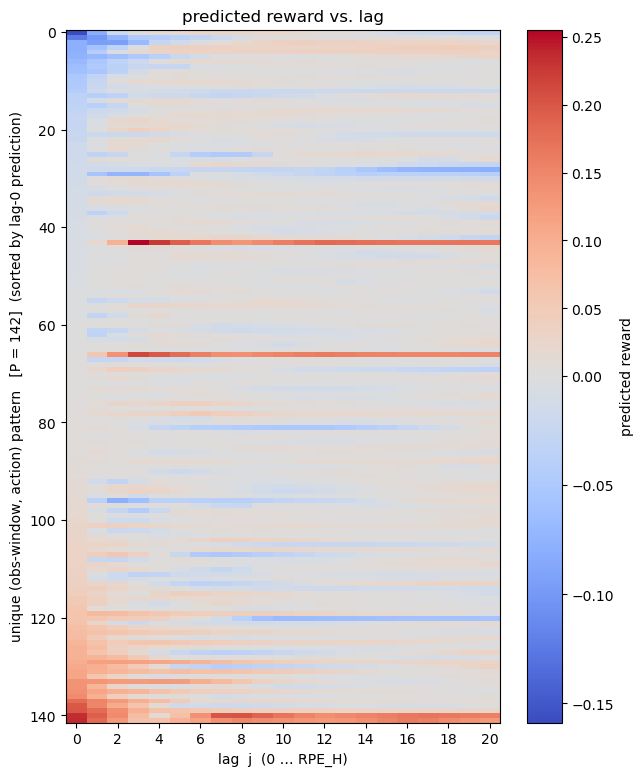

In [7]:
# unique (window, action) patterns, crossed with every lag -> the net's response surface
WA = np.unique(U[:, :act_end], axis=0)                        # (P, K*obs + A)
P = WA.shape[0]
lags = np.arange(RPE_H + 1) / max(RPE_H, 1)
grid = np.concatenate([
    np.repeat(WA, RPE_H + 1, axis=0),
    np.tile(lags, P)[:, None].astype(np.float32),
], axis=1)                                                    # (P*(H+1), WINDOW_DIM)
resp = np.asarray(predict_reward(jnp.asarray(grid))).reshape(P, RPE_H + 1)

row_order = np.argsort(resp[:, 0])                            # sort by lag-0 prediction
resp_s = resp[row_order]

fig, ax = plt.subplots(figsize=(7, 9))
norm = TwoSlopeNorm(vmin=min(resp.min(), -1e-6), vcenter=0.0, vmax=max(resp.max(), 1e-6))
im = ax.imshow(resp_s, aspect='auto', cmap='coolwarm', norm=norm, interpolation='nearest')
ax.set_xlabel('lag  j  (0 … RPE_H)'); ax.set_xticks(range(0, RPE_H + 1, 2))
ax.set_ylabel(f'unique (obs-window, action) pattern   [P = {P}]  (sorted by lag-0 prediction)')
ax.set_title('predicted reward vs. lag')
fig.colorbar(im, ax=ax, label='predicted reward')
plt.show()

## Highest / lowest predicted-reward input patterns

In [8]:
def describe(row):
    w = row[:RPE_K * OBS].reshape(RPE_K, OBS)
    a = int(np.argmax(row[act_end - ACT:act_end]))
    lag = row[-1] * RPE_H
    return f'window(t-3..t)=\n{w.astype(int)}  action={a}  lag={lag:.0f}'

po = np.argsort(pred)
print('=== TOP 3 predicted reward ===')
for i in po[::-1][:3]:
    print(f'pred={pred[i]:+.4f}  ' + describe(U[i]).replace(chr(10), ' '))
print('\n=== BOTTOM 3 predicted reward ===')
for i in po[:3]:
    print(f'pred={pred[i]:+.4f}  ' + describe(U[i]).replace(chr(10), ' '))

=== TOP 3 predicted reward ===
pred=+0.2555  window(t-3..t)= [[1 0 0 1]  [1 0 0 1]  [1 0 0 1]  [1 0 0 1]]  action=1  lag=3
pred=+0.2365  window(t-3..t)= [[1 0 1 0]  [1 0 1 0]  [1 0 1 0]  [1 0 1 0]]  action=0  lag=0
pred=+0.2348  window(t-3..t)= [[1 0 0 1]  [1 0 0 1]  [1 0 0 1]  [1 0 0 1]]  action=0  lag=0

=== BOTTOM 3 predicted reward ===
pred=-0.1231  window(t-3..t)= [[1 0 0 0]  [1 1 0 0]  [1 1 0 0]  [1 1 0 0]]  action=0  lag=0
pred=-0.0993  window(t-3..t)= [[1 0 0 0]  [1 1 0 0]  [1 1 0 0]  [1 1 0 0]]  action=0  lag=1
pred=-0.0955  window(t-3..t)= [[1 1 0 0]  [1 1 0 0]  [1 1 0 0]  [1 1 0 0]]  action=0  lag=1
